In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)



In [ ]:
df = pd.read_csv("Credis_Score_Dataset_B.csv")
df


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xc765,CUS_0xade3,April,Kevin Limx,49,#F%$D@*&8,Entrepreneur,165076.44,NaN,1,...,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.5113527934434,Low_spent_Large_value_payments,248.55092985209012,Standard
1,0x1fbf9,CUS_0x7651,April,Slaterv,40,300-72-2019,Manager,57321.36,4666.780000,10,...,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.80243048143443,High_spent_Medium_value_payments,226.9868910810159,Standard
2,0x15891,CUS_0x84fe,April,Leee,38,579-44-7984,_______,30111.3,NaN,7,...,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,__10000__,High_spent_Small_value_payments,257.0932938020279,Poor
3,0x3ee7,CUS_0x7620,June,Fionag,24,#F%$D@*&8,Developer,36496.38_,2934.365000,8,...,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.7583756600934,Poor
4,0x1e5aa,CUS_0x5572,May,Hyunjoo Jina,39,972-53-4211,Scientist,10068.97,NaN,8,...,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.55878243363996,Low_spent_Medium_value_payments,294.2270494281999,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0x993b,CUS_0x710e,June,Papadimasx,44,840-65-9735,Doctor,41678.65,3672.220833,2,...,Good,1209.49,37.547392,21 Years and 1 Months,No,76.058271,146.10019412347015,Low_spent_Small_value_payments,435.0636180428778,Standard
49996,0x22db9,CUS_0x457e,August,Flitterq,54_,656-83-9494,Journalist,59343.12,4919.260000,7,...,Standard,9.32,39.561824,21 Years and 3 Months,Yes,0.000000,123.45654719780038,High_spent_Medium_value_payments,618.4694528021996,Standard
49997,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,6,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.9176651596068,Standard
49998,0x1a30,CUS_0x3861,March,Fiona Ortizx,-500,212-32-2085,Engineer,17992.775,1769.397917,3,...,_,565.22,23.136824,19 Years and 1 Months,No,0.000000,95.65646110813336,High_spent_Small_value_payments,341.28333055853335,Poor


In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xc765,CUS_0xade3,April,Kevin Limx,49,#F%$D@*&8,Entrepreneur,165076.44,NaN,1,...,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.5113527934434,Low_spent_Large_value_payments,248.55092985209012,Standard
1,0x1fbf9,CUS_0x7651,April,Slaterv,40,300-72-2019,Manager,57321.36,4666.780,10,...,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.80243048143443,High_spent_Medium_value_payments,226.9868910810159,Standard
2,0x15891,CUS_0x84fe,April,Leee,38,579-44-7984,_______,30111.3,NaN,7,...,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,__10000__,High_spent_Small_value_payments,257.0932938020279,Poor
3,0x3ee7,CUS_0x7620,June,Fionag,24,#F%$D@*&8,Developer,36496.38_,2934.365,8,...,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.7583756600934,Poor
4,0x1e5aa,CUS_0x5572,May,Hyunjoo Jina,39,972-53-4211,Scientist,10068.97,NaN,8,...,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.55878243363996,Low_spent_Medium_value_payments,294.2270494281999,Standard


In [ ]:
df = df.drop(columns=["ID", "Customer_ID", "Name"])


In [ ]:
df.head()

,Month,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,April,49,#F%$D@*&8,Entrepreneur,165076.44,NaN,1,6,3,-100,...,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.5113527934434,Low_spent_Large_value_payments,248.55092985209012,Standard
1,April,40,300-72-2019,Manager,57321.36,4666.780,10,10,22,9,...,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.80243048143443,High_spent_Medium_value_payments,226.9868910810159,Standard
2,April,38,579-44-7984,_______,30111.3,NaN,7,5,15,9,...,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,__10000__,High_spent_Small_value_payments,257.0932938020279,Poor
3,June,24,#F%$D@*&8,Developer,36496.38_,2934.365,8,3,30,3,...,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.7583756600934,Poor
4,May,39,972-53-4211,Scientist,10068.97,NaN,8,4,7,3,...,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.55878243363996,Low_spent_Medium_value_payments,294.2270494281999,Standard


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       50000 non-null  object 
 2   SSN                       50000 non-null  object 
 3   Occupation                50000 non-null  object 
 4   Annual_Income             50000 non-null  object 
 5   Monthly_Inhand_Salary     42512 non-null  float64
 6   Num_Bank_Accounts         50000 non-null  int64  
 7   Num_Credit_Card           50000 non-null  int64  
 8   Interest_Rate             50000 non-null  int64  
 9   Num_of_Loan               50000 non-null  object 
 10  Type_of_Loan              44324 non-null  object 
 11  Delay_from_due_date       50000 non-null  int64  
 12  Num_of_Delayed_Payment    46398 non-null  object 
 13  Changed_Credit_Limit      50000 non-null  object 
 14  Num_Cr

There are errors in the data types (dtypes) of the following columns:

1. Age

2. Annual_Income

3. Num_of_Loan

4. Num_of_Delayed_Payment

5. Changed_Credit_Limit

6. Amount_invested_monthly

7. Monthly_Balance

8. Outstanding_Debt

In [ ]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Annual_Income"] = pd.to_numeric(df["Annual_Income"], errors="coerce")
df["Num_of_Loan"] = pd.to_numeric(df["Num_of_Loan"], errors="coerce")
df["Num_of_Delayed_Payment"] = pd.to_numeric(df["Num_of_Delayed_Payment"], errors="coerce")
df["Changed_Credit_Limit"] = pd.to_numeric(df["Changed_Credit_Limit"], errors="coerce")
df["Amount_invested_monthly"] = pd.to_numeric(df["Amount_invested_monthly"], errors="coerce")
df["Monthly_Balance"] = pd.to_numeric(df["Monthly_Balance"], errors="coerce")
df["Outstanding_Debt"] = pd.to_numeric(df["Outstanding_Debt"], errors="coerce")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       47517 non-null  float64
 2   SSN                       50000 non-null  object 
 3   Occupation                50000 non-null  object 
 4   Annual_Income             46482 non-null  float64
 5   Monthly_Inhand_Salary     42512 non-null  float64
 6   Num_Bank_Accounts         50000 non-null  int64  
 7   Num_Credit_Card           50000 non-null  int64  
 8   Interest_Rate             50000 non-null  int64  
 9   Num_of_Loan               47583 non-null  float64
 10  Type_of_Loan              44324 non-null  object 
 11  Delay_from_due_date       50000 non-null  int64  
 12  Num_of_Delayed_Payment    45032 non-null  float64
 13  Changed_Credit_Limit      48972 non-null  float64
 14  Num_Cr

In [ ]:
def show_all_unique_object_values(df):
    obj_cols = df.select_dtypes(include=["object"]).columns

    for col in obj_cols:
        uniques = df[col].dropna().unique()
        print(f"\nKolom: {col}")
        print(f"Jumlah unik: {len(uniques)}")
        print("Semua nilai unik:")
        print(uniques)
show_all_unique_object_values(df)



Kolom: Month
Jumlah unik: 8
Semua nilai unik:
['April' 'June' 'May' 'August' 'February' 'January' 'July' 'March']

Kolom: SSN
Jumlah unik: 12415
Semua nilai unik:
['#F%$D@*&8' '300-72-2019' '579-44-7984' ... '585-94-4096' '735-58-7826'
 '025-25-9650']

Kolom: Occupation
Jumlah unik: 16
Semua nilai unik:
['Entrepreneur' 'Manager' '_______' 'Developer' 'Scientist' 'Teacher'
 'Lawyer' 'Doctor' 'Engineer' 'Architect' 'Mechanic' 'Musician'
 'Journalist' 'Writer' 'Accountant' 'Media_Manager']

Kolom: Type_of_Loan
Jumlah unik: 6236
Semua nilai unik:
['Personal Loan, and Credit-Builder Loan'
 'Payday Loan, Payday Loan, Payday Loan, Personal Loan, Student Loan, Mortgage Loan, Mortgage Loan, Personal Loan, and Not Specified'
 'Auto Loan, Mortgage Loan, Personal Loan, Not Specified, Mortgage Loan, Mortgage Loan, Not Specified, Mortgage Loan, and Student Loan'
 ...
 'Personal Loan, Personal Loan, Credit-Builder Loan, Payday Loan, Mortgage Loan, Credit-Builder Loan, Payday Loan, and Home Equity Lo

In [ ]:
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace("NM", "No")

In [ ]:
cols = ["SSN", "Occupation", "Credit_Mix", "Payment_Behaviour"]

inconsistent_values = {
    "SSN": ["#F%$D@*&8"],
    "Occupation": ["_______"],
    "Credit_Mix": ["_"],
    "Payment_Behaviour": ["!@9#%8"]
}

for col in cols:
    df[col] = df[col].replace(inconsistent_values[col], np.nan)


In [ ]:
summary = pd.DataFrame({
    "Null Count": df[cols].isna().sum(),
    "Null Percentage": (df[cols].isna().mean() * 100).round(2)
})

summary


,Null Count,Null Percentage
SSN,2805,5.61
Occupation,3481,6.96
Credit_Mix,10042,20.08
Payment_Behaviour,3857,7.71


In [ ]:
df = df.drop(columns=["SSN"])
df["Occupation"] = df["Occupation"].fillna(df["Occupation"].mode()[0])
df["Payment_Behaviour"] = df["Payment_Behaviour"].fillna(df["Payment_Behaviour"].mode()[0])
df["Credit_Mix"] = df["Credit_Mix"].fillna("Unknown")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       47517 non-null  float64
 2   Occupation                50000 non-null  object 
 3   Annual_Income             46482 non-null  float64
 4   Monthly_Inhand_Salary     42512 non-null  float64
 5   Num_Bank_Accounts         50000 non-null  int64  
 6   Num_Credit_Card           50000 non-null  int64  
 7   Interest_Rate             50000 non-null  int64  
 8   Num_of_Loan               47583 non-null  float64
 9   Type_of_Loan              44324 non-null  object 
 10  Delay_from_due_date       50000 non-null  int64  
 11  Num_of_Delayed_Payment    45032 non-null  float64
 12  Changed_Credit_Limit      48972 non-null  float64
 13  Num_Credit_Inquiries      48993 non-null  float64
 14  Credit

In [ ]:
def show_all_unique_numeric_values(df):
    num_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns

    for col in num_cols:
        uniques = np.sort(df[col].dropna().unique())
        print(f"\nKolom: {col}")
        print(f"Jumlah unik: {len(uniques)}")
        print("Semua nilai unik:")
        print(uniques)

show_all_unique_numeric_values(df)



Kolom: Age
Jumlah unik: 908
Semua nilai unik:
[-500.   14.   15.   16.   17.   18.   19.   20.   21.   22.   23.   24.
   25.   26.   27.   28.   29.   30.   31.   32.   33.   34.   35.   36.
   37.   38.   39.   40.   41.   42.   43.   44.   45.   46.   47.   48.
   49.   50.   51.   52.   53.   54.   55.   56.   95.  100.  109.  112.
  123.  126.  142.  169.  189.  194.  203.  208.  216.  221.  223.  252.
  262.  275.  278.  287.  305.  316.  325.  330.  344.  347.  395.  399.
  402.  404.  448.  449.  456.  462.  471.  480.  488.  491.  498.  502.
  514.  525.  528.  529.  532.  535.  540.  553.  556.  568.  573.  581.
  598.  620.  622.  623.  624.  634.  637.  642.  672.  673.  678.  681.
  690.  692.  715.  725.  727.  751.  762.  769.  774.  783.  793.  806.
  831.  836.  846.  849.  879.  886.  890.  919.  920.  925.  933.  940.
  941.  956.  960.  963.  985.  995. 1004. 1022. 1024. 1033. 1040. 1062.
 1083. 1094. 1101. 1110. 1119. 1136. 1143. 1144. 1148. 1170. 1171. 1172.
 117

## **Issues in the numerical columns:**

1. **Age** contains unrealistic values (e.g., below 0 and above 100), indicating invalid entries.
2. **Annual_Income** contains inconsistent formats with underscores (e.g., `_27813_`, `_27813`, `27813_`), which prevents proper numeric conversion.
3. **Num_of_Loan** contains inconsistent formats with underscores and includes unrealistic/out-of-range values.
4. **Num_of_Delayed_Payment** has incorrect data types and may contain non-numeric or inconsistent values.
5. **Changed_Credit_Limit** has incorrect data types and requires standardization of numeric formatting (e.g., rounding to fixed decimals).
6. **Amount_invested_monthly** contains values with underscores (e.g., `_10000_`), which should be treated as missing.
7. **Monthly_Balance** has incorrect data types and may include invalid or inconsistent numeric entries.
8. **Outstanding_Debt** has incorrect data types and may contain non-numeric or improperly formatted values.
9. **Interest_Rate** contains unrealistic values (e.g., values like 4091 instead of 40.91), suggesting a scaling or formatting issue.
10. **Num_Credit_Card** includes unusually large values, which are not realistic for the number of credit cards held by one person.
11. **Num_Credit_Inquiries** may contain unusually high values and should be checked for outliers based on the dataset time period.


In [ ]:
df.loc[(df["Age"] < 0) | (df["Age"] > 100), "Age"] = np.nan

In [ ]:
df["Annual_Income"] = (
    df["Annual_Income"]
    .astype(str)
    .str.strip("_")
)

In [ ]:
df["Num_of_Loan"] = (
    df["Num_of_Loan"]
    .astype(str)
    .str.strip("_")
)

In [ ]:
df["Num_of_Delayed_Payment"] = (
    df["Num_of_Delayed_Payment"]
    .astype(str)
    .str.strip("_")
)

df["Num_of_Delayed_Payment"] = pd.to_numeric(df["Num_of_Delayed_Payment"], errors="coerce")

df.loc[df["Num_of_Delayed_Payment"] < 0, "Num_of_Delayed_Payment"] = np.nan


In [ ]:
df.loc[df["Delay_from_due_date"] < 0, "Delay_from_due_date"] = np.nan

In [ ]:
df["Changed_Credit_Limit"] = (
    df["Changed_Credit_Limit"]
    .astype(str)
    .str.strip("_")
)

In [ ]:
df["Outstanding_Debt"] = (
    df["Outstanding_Debt"]
    .astype(str)
    .str.strip("_")
)

In [ ]:
df.loc[df["Amount_invested_monthly"].astype(str).str.contains("_"), "Amount_invested_monthly"] = np.nan

In [ ]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Annual_Income"] = pd.to_numeric(df["Annual_Income"], errors="coerce")
df["Num_of_Loan"] = pd.to_numeric(df["Num_of_Loan"], errors="coerce")
df["Num_of_Delayed_Payment"] = pd.to_numeric(df["Num_of_Delayed_Payment"], errors="coerce")
df["Changed_Credit_Limit"] = pd.to_numeric(df["Changed_Credit_Limit"], errors="coerce")
df["Amount_invested_monthly"] = pd.to_numeric(df["Amount_invested_monthly"], errors="coerce")
df["Monthly_Balance"] = pd.to_numeric(df["Monthly_Balance"], errors="coerce")
df["Outstanding_Debt"] = pd.to_numeric(df["Outstanding_Debt"], errors="coerce")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       46184 non-null  float64
 2   Occupation                50000 non-null  object 
 3   Annual_Income             46482 non-null  float64
 4   Monthly_Inhand_Salary     42512 non-null  float64
 5   Num_Bank_Accounts         50000 non-null  int64  
 6   Num_Credit_Card           50000 non-null  int64  
 7   Interest_Rate             50000 non-null  int64  
 8   Num_of_Loan               47583 non-null  float64
 9   Type_of_Loan              44324 non-null  object 
 10  Delay_from_due_date       49711 non-null  float64
 11  Num_of_Delayed_Payment    44726 non-null  float64
 12  Changed_Credit_Limit      48972 non-null  float64
 13  Num_Credit_Inquiries      48993 non-null  float64
 14  Credit

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
cat_null = pd.DataFrame({
    "Null Count": df[cat_cols].isna().sum(),
    "Null Percentage (%)": (df[cat_cols].isna().mean() * 100).round(2)
}).sort_values(by="Null Percentage (%)", ascending=False)
num_null = pd.DataFrame({
    "Null Count": df[num_cols].isna().sum(),
    "Null Percentage (%)": (df[num_cols].isna().mean() * 100).round(2)
}).sort_values(by="Null Percentage (%)", ascending=False)

print("CATEGORICAL COLUMNS")
display(cat_null)

print("\nNUMERICAL COLUMNS")
display(num_null)


CATEGORICAL COLUMNS


,Null Count,Null Percentage (%)
Type_of_Loan,5676,11.35
Credit_History_Age,4464,8.93
Occupation,0,0.00
Month,0,0.00
Credit_Mix,0,0.00
Payment_of_Min_Amount,0,0.00
Payment_Behaviour,0,0.00
Credit_Score,0,0.00



NUMERICAL COLUMNS


,Null Count,Null Percentage (%)
Monthly_Inhand_Salary,7488,14.98
Num_of_Delayed_Payment,5274,10.55
Amount_invested_monthly,4353,8.71
Age,3816,7.63
Annual_Income,3518,7.04
Num_of_Loan,2417,4.83
Changed_Credit_Limit,1028,2.06
Num_Credit_Inquiries,1007,2.01
Monthly_Balance,615,1.23
Outstanding_Debt,508,1.02


In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
num_cols = df.select_dtypes(include=[np.number]).columns

for col in cat_cols:
    if df[col].isna().sum() > 0:
        mode_val = df[col].mode(dropna=True)[0]
        df[col] = df[col].fillna(mode_val)

for col in num_cols:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("Missing values sudah diisi: categorical=mode, numerical=median")


Missing values sudah diisi: categorical=mode, numerical=median


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       50000 non-null  float64
 2   Occupation                50000 non-null  object 
 3   Annual_Income             50000 non-null  float64
 4   Monthly_Inhand_Salary     50000 non-null  float64
 5   Num_Bank_Accounts         50000 non-null  int64  
 6   Num_Credit_Card           50000 non-null  int64  
 7   Interest_Rate             50000 non-null  int64  
 8   Num_of_Loan               50000 non-null  float64
 9   Type_of_Loan              50000 non-null  object 
 10  Delay_from_due_date       50000 non-null  float64
 11  Num_of_Delayed_Payment    50000 non-null  float64
 12  Changed_Credit_Limit      50000 non-null  float64
 13  Num_Credit_Inquiries      50000 non-null  float64
 14  Credit

In [ ]:
cols = ["Num_Credit_Card", "Num_Bank_Accounts", "Interest_Rate", "Num_Credit_Inquiries", "Num_of_Delayed_Payment", "Annual_Income", "Monthly_Balance",
"Outstanding_Debt"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR

    df.loc[df[col] > upper, col] = np.nan

    df[col] = df[col].fillna(df[col].median())

In [ ]:
#Categorical
def convert_credit_history_age(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    years = 0
    months = 0

    if "Years" in x:
        years = int(x.split("Years")[0].strip())
    if "Months" in x:
        months = int(x.split("Months")[0].split()[-1].strip())

    return years * 12 + months

df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_credit_history_age)
df["Credit_History_Age"] = df["Credit_History_Age"].fillna(df["Credit_History_Age"].median())



**Reason (Missing Value Handling):**

For numeric-related information stored as text (such as **Credit_History_Age**), the values were converted into numeric form and missing entries were imputed using the **median**, which is more robust to outliers and helps maintain realistic values without being heavily affected by extreme data points. While **Name** is dropped because it is identifier.



To handle unrealistic extreme values in Num_Credit_Card and Num_Bank_Accounts, an outlier treatment was applied using the IQR method. Values above the upper bound (Q3 + 1.5×IQR) were considered abnormal because having hundreds of credit cards or bank accounts is not logically reasonable in real-world scenarios, indicating potential data errors or noise. Therefore, these extreme values were replaced with missing values (NaN) and then imputed using the median, which is a robust statistic that reduces the influence of outliers. This approach helps stabilize the distribution of these features and prevents extreme values from distorting clustering results and scaling during preprocessing.

In [ ]:
import re

def count_loans(type_str):
    if pd.isna(type_str) or str(type_str).strip() == "":
        return 0

    s = str(type_str).strip()
    s = re.sub(r"\s+and\s+", ",", s)
    items = [x.strip() for x in s.split(",") if x.strip() != ""]
    return len(items)

df["Loan_Count_From_Type"] = df["Type_of_Loan"].apply(count_loans)


In [ ]:
df["Num_of_Loan"] = df["Loan_Count_From_Type"]


In [ ]:
df["Num_of_Loan"].unique()

array([2, 9, 3, 4, 7, 5, 1, 6, 8])

In [ ]:
df = df.drop(columns=["Type_of_Loan", "Loan_Count_From_Type"])

I dropped the Type_of_Loan column because it contains a very large number of unique values and many different combinations of loan types in a single text field. If I apply one-hot encoding to this feature, it will create too many new dummy columns, which can significantly increase the dataset dimensionality, slow down the training process, and require much more memory and computational time. Therefore, removing this column helps keep the preprocessing step more efficient and makes the model training faster and more manageable.

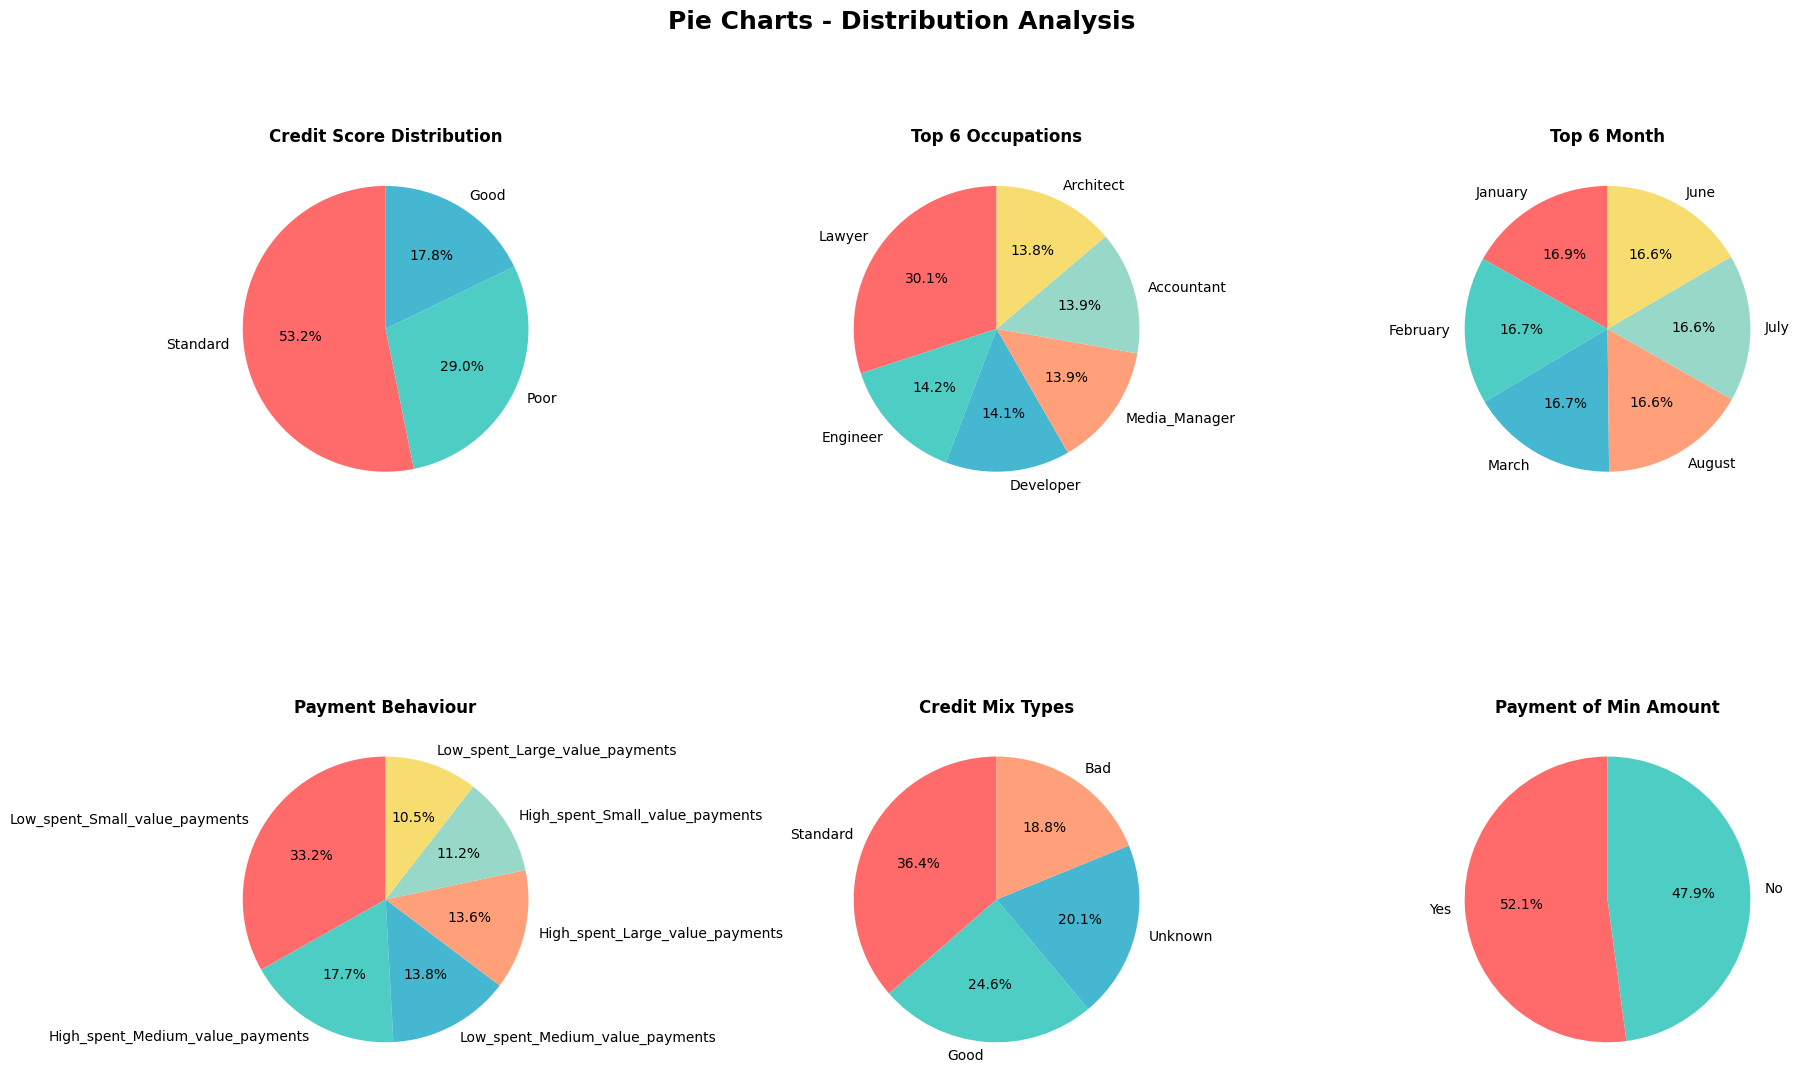

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Pie Charts - Distribution Analysis', fontsize=18, fontweight='bold')

colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

# Credit Score Distribution
if 'Credit_Score' in df.columns:
    credit_data = df['Credit_Score'].value_counts()
    axes[0, 0].pie(credit_data.values, labels=credit_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette[:len(credit_data)])
    axes[0, 0].set_title('Credit Score Distribution', fontsize=12, fontweight='bold')

# Occupation Distribution
if 'Occupation' in df.columns:
    occ_data = df['Occupation'].value_counts().head(6)
    axes[0, 1].pie(occ_data.values, labels=occ_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette)
    axes[0, 1].set_title('Top 6 Occupations', fontsize=12, fontweight='bold')

# Month Distribution
if 'Month' in df.columns:
    month_data = df['Month'].value_counts().head(6)
    axes[0, 2].pie(month_data.values, labels=month_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette)
    axes[0, 2].set_title('Top 6 Month', fontsize=12, fontweight='bold')

# Payment Behaviour Distribution
if 'Payment_Behaviour' in df.columns:
    payment_data = df['Payment_Behaviour'].value_counts().head(6)
    axes[1, 0].pie(payment_data.values, labels=payment_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette)
    axes[1, 0].set_title('Payment Behaviour', fontsize=12, fontweight='bold')

# Credit Mix Distribution
if 'Credit_Mix' in df.columns:
    mix_data = df['Credit_Mix'].value_counts()
    axes[1, 1].pie(mix_data.values, labels=mix_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette[:len(mix_data)])
    axes[1, 1].set_title('Credit Mix Types', fontsize=12, fontweight='bold')

# Payment of Min Amount Distribution
if 'Payment_of_Min_Amount' in df.columns:
    min_payment_data = df['Payment_of_Min_Amount'].value_counts()
    axes[1, 2].pie(min_payment_data.values, labels=min_payment_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette[:len(min_payment_data)])
    axes[1, 2].set_title('Payment of Min Amount', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



* **Credit Score Distribution** is dominated by **Standard (53.2%)**, followed by **Poor (29.0%)**, while **Good (17.8%)** is the smallest segment, showing the customer base is mostly average-to-medium credit quality.

* **Top 6 Occupations** shows a strong concentration in **Lawyer (30.1%)**, while the other occupations (**Engineer, Developer, Media Manager, Accountant, Architect**) are relatively evenly distributed (~13–14% each), indicating one occupation group is highly overrepresented.

* **Top 6 Month Distribution** (January–August) is almost evenly split (~16.6–16.9% each), suggesting **no strong seasonal bias** or major monthly spikes in the dataset for these months.

* **Payment Behaviour** is led by **Low_spent_Small_value_payments (33.2%)**, meaning many customers frequently make small-value payments with lower spending levels.

* The remaining payment behaviour categories are spread across multiple groups (high/low spend and medium/large value), indicating **diverse customer spending patterns** rather than one single dominant behaviour type.

* **Credit Mix Types** are mostly **Standard (36.4%)**, followed by **Good (24.6%)**, **Unknown (20.1%)**, and **Bad (18.8%)**, showing a fairly mixed population with a considerable amount of unclear/uncertain credit mix information.

* **Payment of Minimum Amount** is nearly balanced: **Yes (52.1%)** vs **No (47.9%)**, meaning about half of the customers regularly pay only the minimum due, which could be a signal of **potential repayment stress** for a large segment.

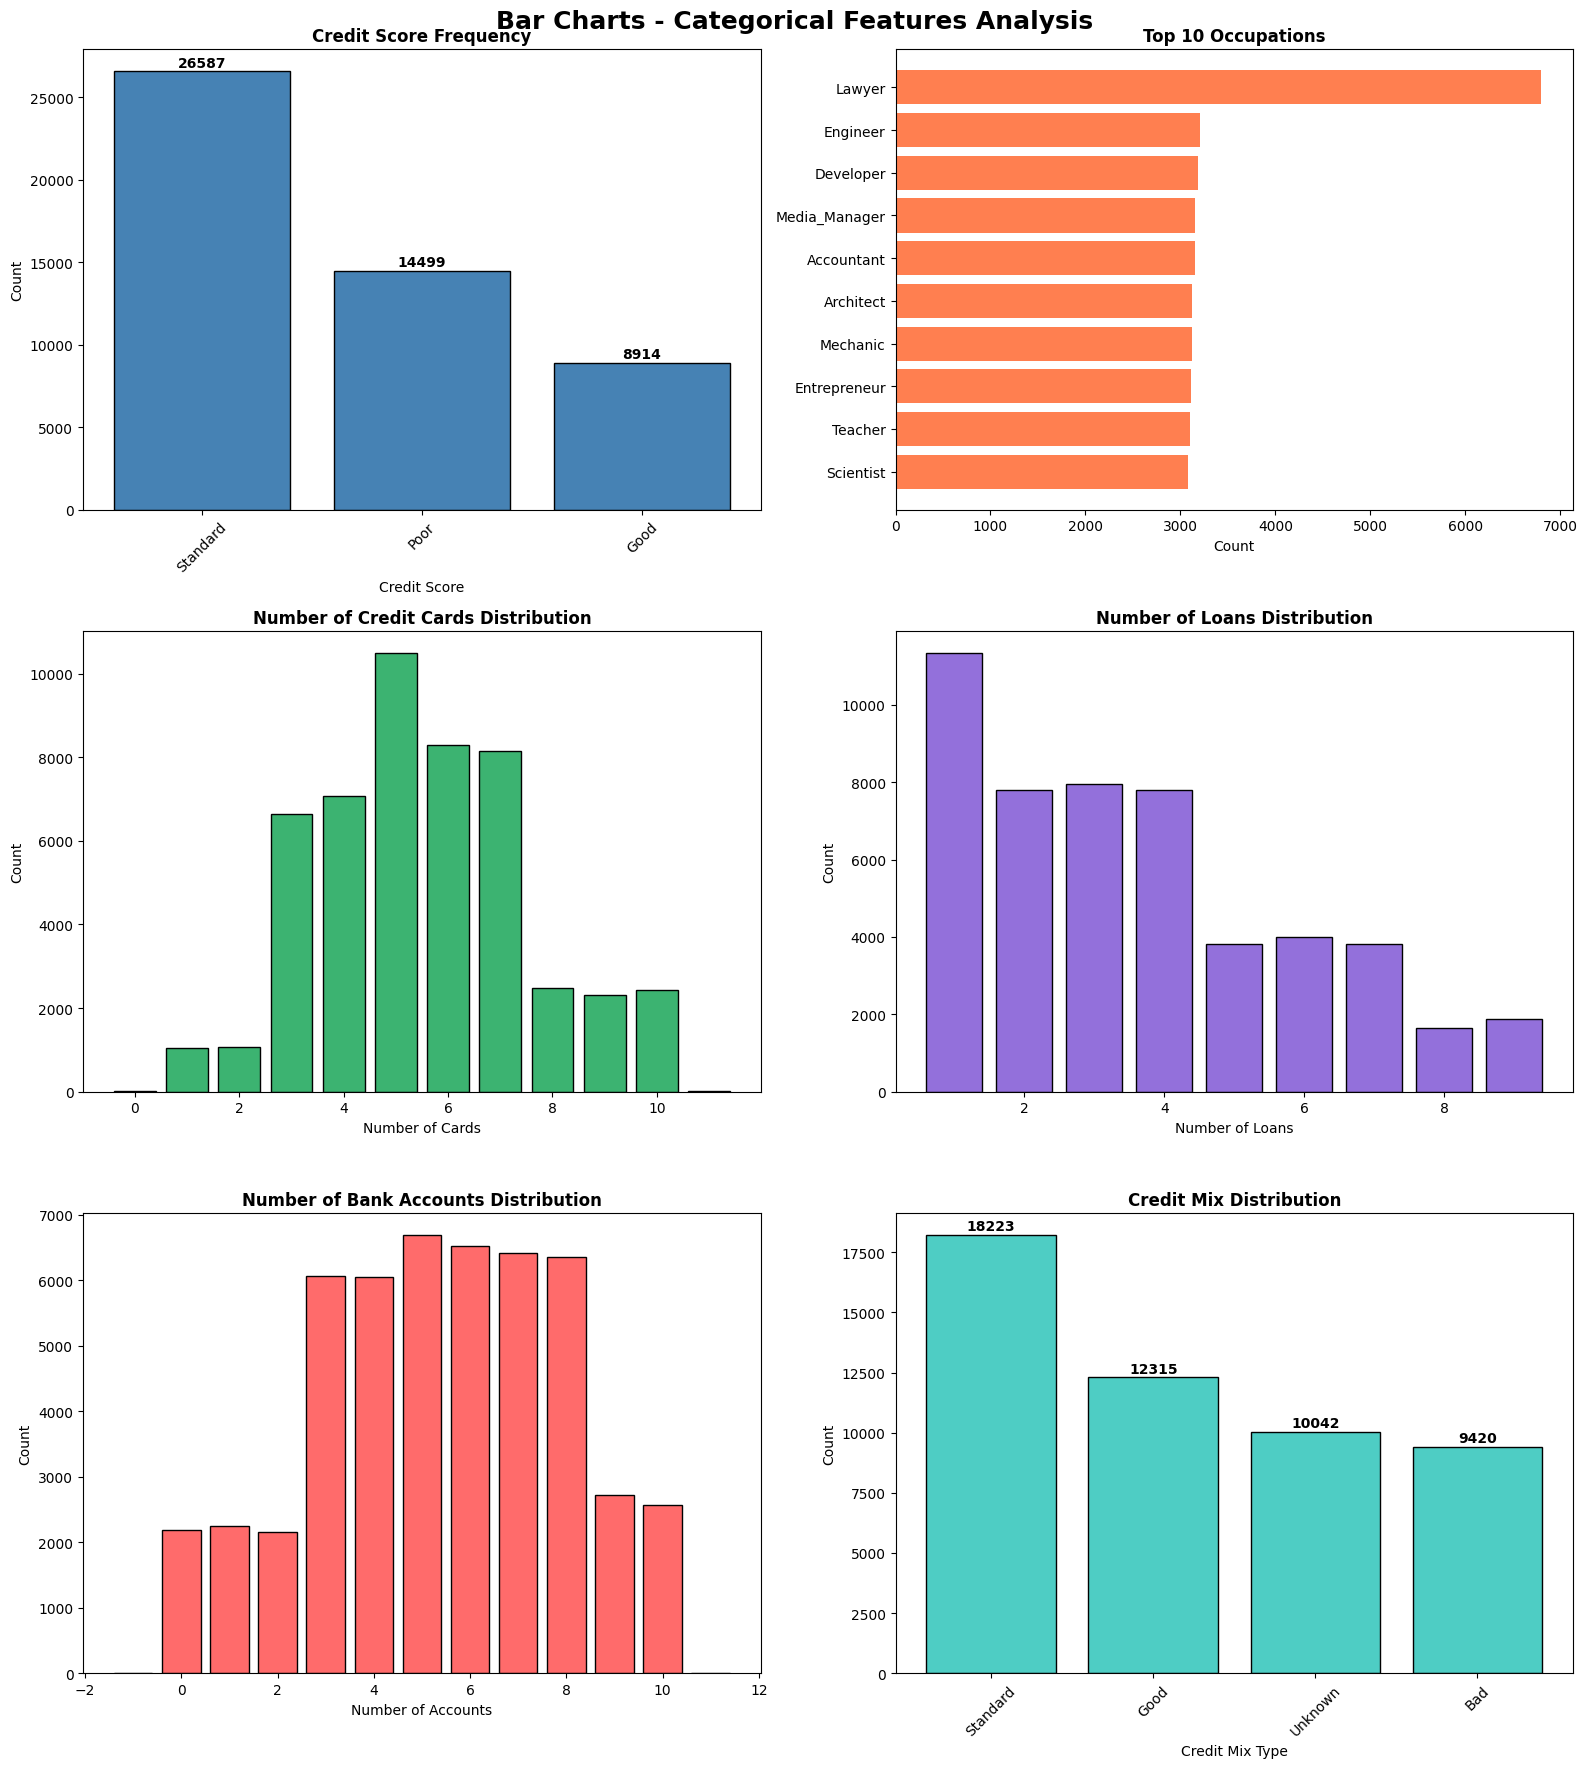

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Bar Charts - Categorical Features Analysis', fontsize=18, fontweight='bold')

# Credit Score Count
if 'Credit_Score' in df.columns:
    score_counts = df['Credit_Score'].value_counts()
    axes[0, 0].bar(score_counts.index, score_counts.values, color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Credit Score Frequency', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Credit Score')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(score_counts.values):
        axes[0, 0].text(i, v + max(score_counts.values)*0.01, str(v), ha='center', fontweight='bold')

# Occupation Distribution
if 'Occupation' in df.columns:
    occ_counts = df['Occupation'].value_counts().head(10)
    axes[0, 1].barh(range(len(occ_counts)), occ_counts.values, color='coral')
    axes[0, 1].set_yticks(range(len(occ_counts)))
    axes[0, 1].set_yticklabels(occ_counts.index)
    axes[0, 1].set_title('Top 10 Occupations', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Count')
    axes[0, 1].invert_yaxis()

# Number of Credit Cards Distribution
if 'Num_Credit_Card' in df.columns:
    card_counts = df['Num_Credit_Card'].value_counts().sort_index().head(15)
    axes[1, 0].bar(card_counts.index, card_counts.values, color='mediumseagreen', edgecolor='black')
    axes[1, 0].set_title('Number of Credit Cards Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Cards')
    axes[1, 0].set_ylabel('Count')

# Number of Loans Distribution
if 'Num_of_Loan' in df.columns:
    loan_counts = df['Num_of_Loan'].value_counts().sort_index().head(15)
    axes[1, 1].bar(loan_counts.index, loan_counts.values, color='mediumpurple', edgecolor='black')
    axes[1, 1].set_title('Number of Loans Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Loans')
    axes[1, 1].set_ylabel('Count')

# Number of Bank Accounts Distribution
if 'Num_Bank_Accounts' in df.columns:
    bank_counts = df['Num_Bank_Accounts'].value_counts().sort_index().head(15)
    axes[2, 0].bar(bank_counts.index, bank_counts.values, color='#FF6B6B', edgecolor='black')
    axes[2, 0].set_title('Number of Bank Accounts Distribution', fontsize=12, fontweight='bold')
    axes[2, 0].set_xlabel('Number of Accounts')
    axes[2, 0].set_ylabel('Count')

# Credit Mix Distribution
if 'Credit_Mix' in df.columns:
    mix_counts = df['Credit_Mix'].value_counts()
    axes[2, 1].bar(mix_counts.index, mix_counts.values, color='#4ECDC4', edgecolor='black')
    axes[2, 1].set_title('Credit Mix Distribution', fontsize=12, fontweight='bold')
    axes[2, 1].set_xlabel('Credit Mix Type')
    axes[2, 1].set_ylabel('Count')
    axes[2, 1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(mix_counts.values):
        axes[2, 1].text(i, v + max(mix_counts.values)*0.01, str(v), ha='center', fontweight='bold')

plt.tight_layout()


* The **credit score distribution is imbalanced**, with **Standard** being the dominant category (`~26,587 customers`), followed by **Poor** (`~14,499`), while **Good** is the smallest group (`~8,914`).

* The dataset contains a **large portion of customers with Poor credit scores**, which may indicate a **higher-risk population** and potential challenges for credit-related decision making.

* **Lawyer** is the most common occupation by a large margin, while the other top occupations (Engineer, Developer, Media Manager, Accountant, Architect, Mechanic, Entrepreneur, Teacher, Scientist) have relatively similar frequencies.

* The occupation distribution suggests the dataset may be **professionally skewed** (not evenly representing all job types), which could affect fairness or generalization in modeling.

* The **number of credit cards** is mostly concentrated around **3–8 cards**, with the peak occurring in the mid-range, meaning most customers own a moderate number of cards.

* The **number of loans** shows a decreasing pattern: **1 loan is the most common**, and the frequency generally drops as the number of loans increases, indicating most customers have **low to moderate borrowing activity**.

* The **number of bank accounts** is concentrated around **4–8 accounts**, suggesting most customers manage multiple financial accounts, but extremely high values are rare.

* The **credit mix distribution** is led by **Standard** (`~18,223`), followed by **Good** (`~12,315`), while **Unknown** (`~10,042`) and **Bad** (`~9,420`) are also substantial segments.


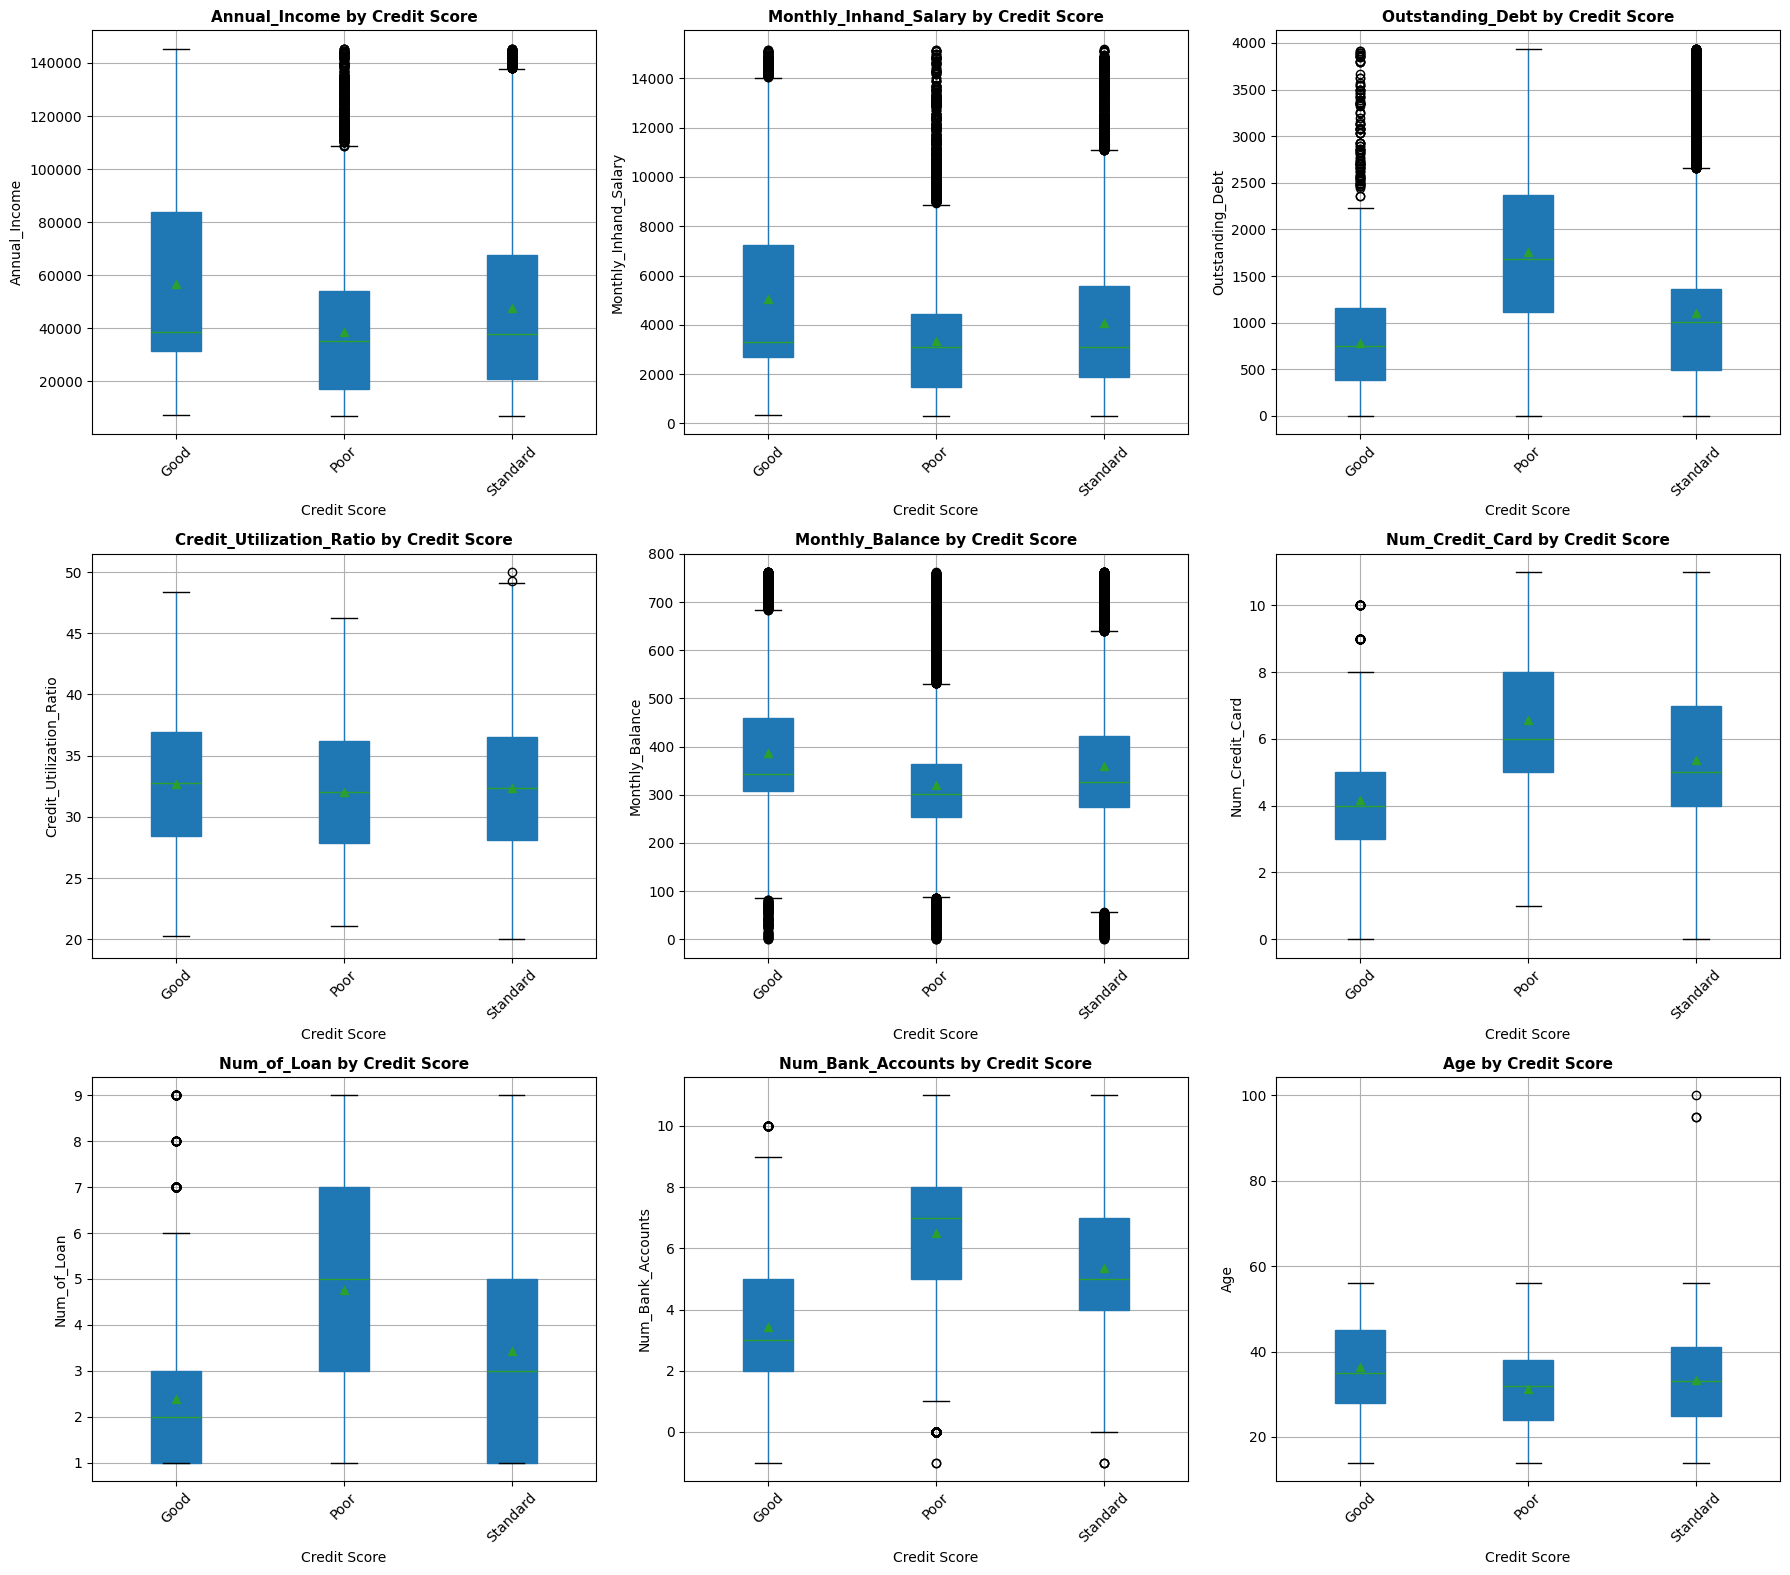

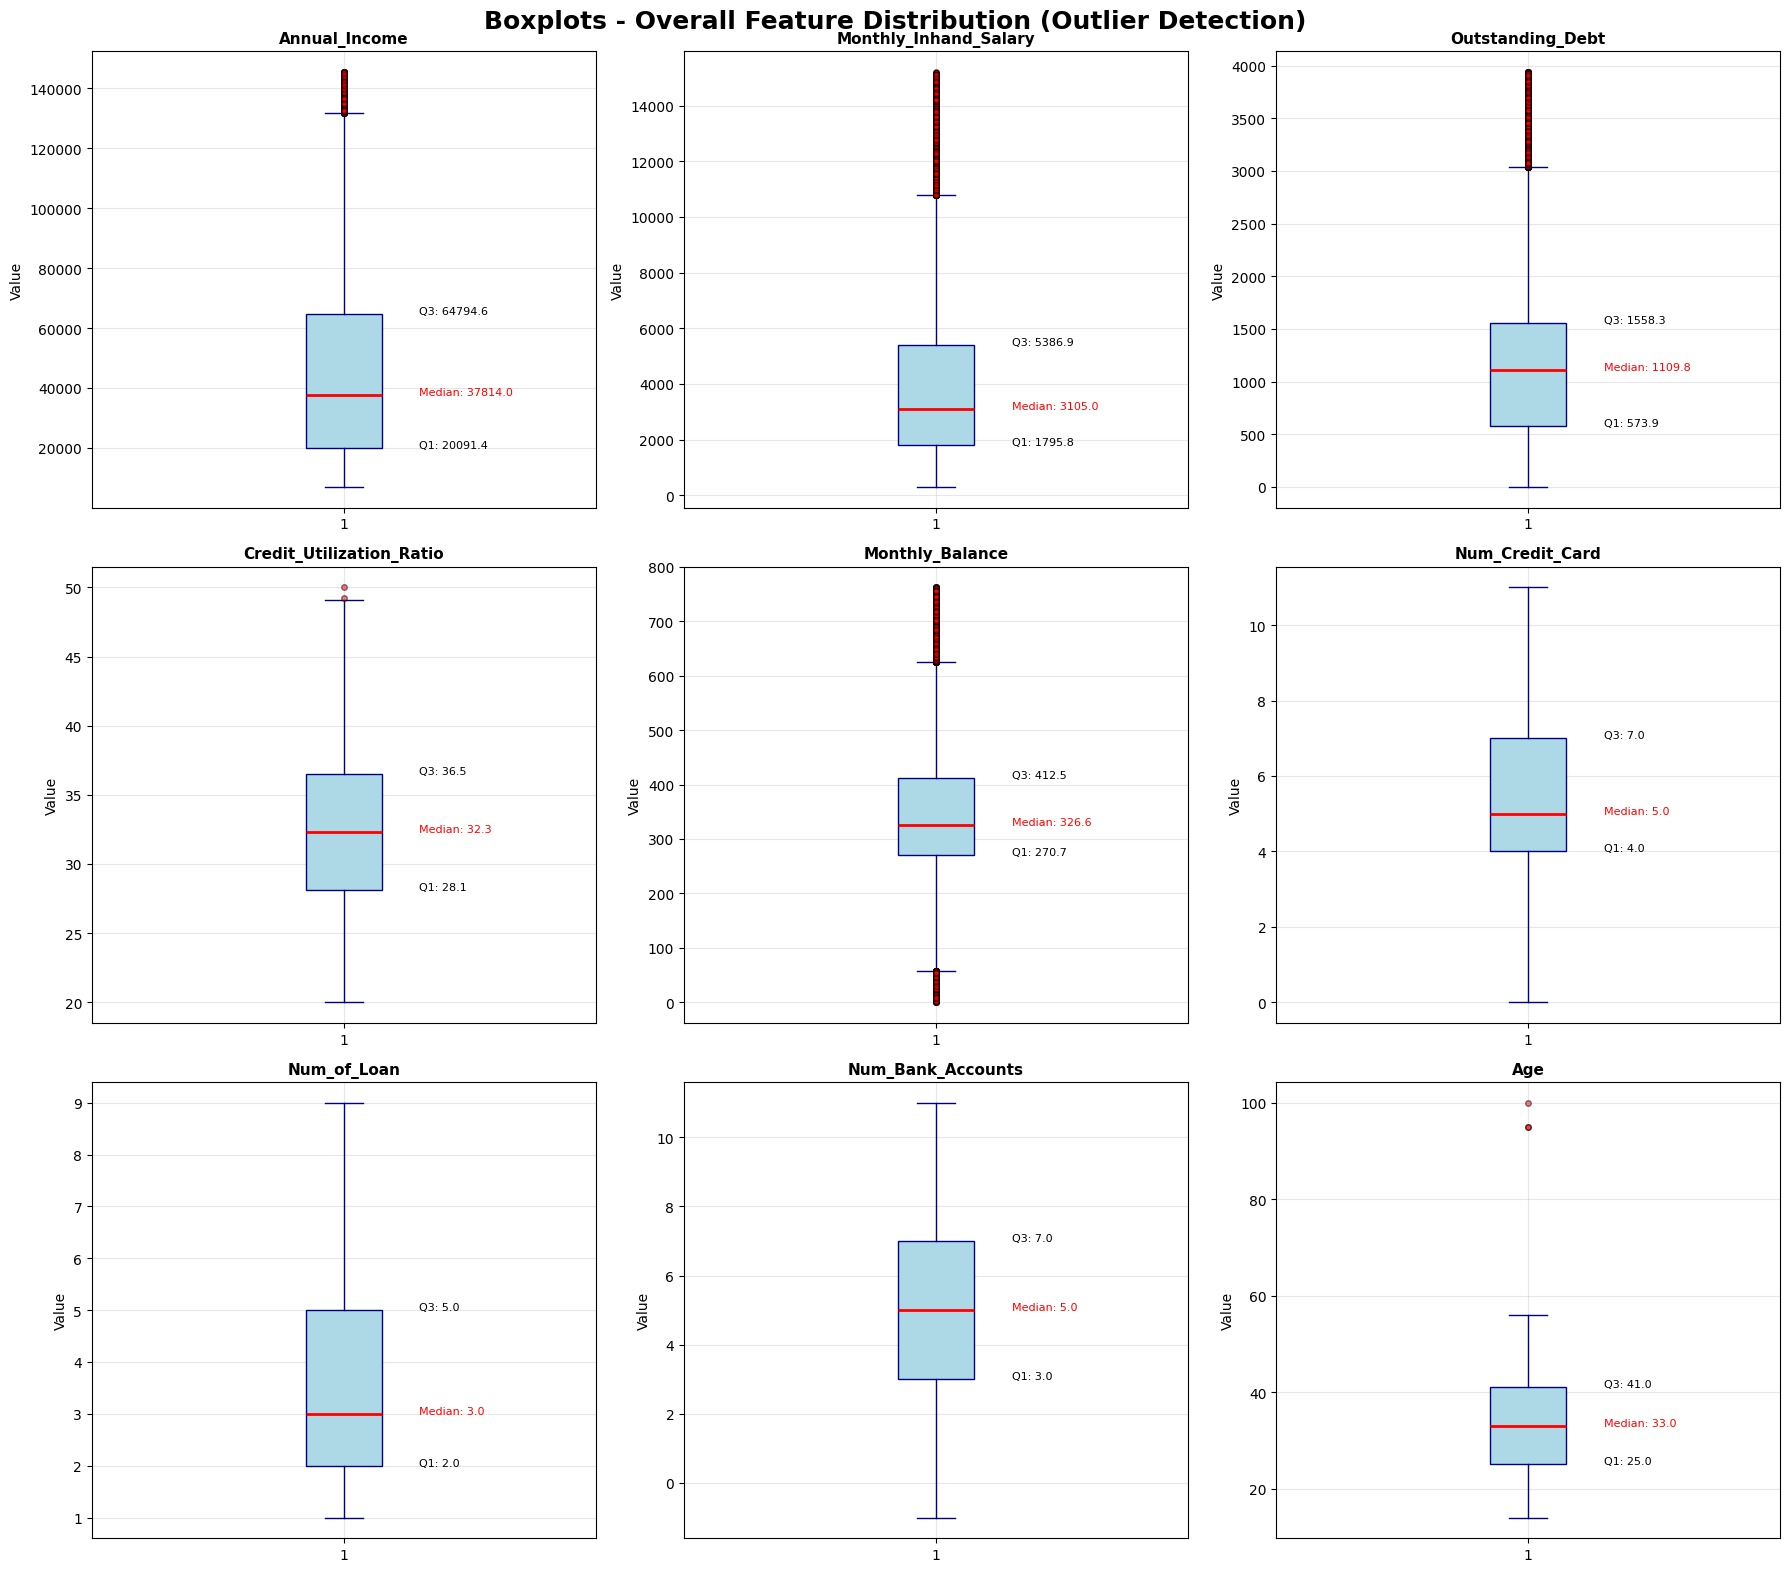

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('Boxplot - Credit Score vs Numerical Features', fontsize=18, fontweight='bold')

boxplot_features = ['Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt',
                    'Credit_Utilization_Ratio', 'Monthly_Balance', 'Num_Credit_Card',
                    'Num_of_Loan', 'Num_Bank_Accounts', 'Age']

for idx, feature in enumerate(boxplot_features):
    if feature in df.columns and 'Credit_Score' in df.columns:
        row, col = idx // 3, idx % 3
        df.boxplot(column=feature, by='Credit_Score', ax=axes[row, col],
                   patch_artist=True, showmeans=True)
        axes[row, col].set_title(f'{feature} by Credit Score', fontsize=11, fontweight='bold')
        axes[row, col].set_xlabel('Credit Score', fontsize=10)
        axes[row, col].set_ylabel(feature, fontsize=10)
        axes[row, col].tick_params(axis='x', rotation=45)
        axes[row, col].get_figure().suptitle('')

plt.tight_layout()

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('Boxplots - Overall Feature Distribution (Outlier Detection)', fontsize=18, fontweight='bold')

for idx, feature in enumerate(boxplot_features):
    if feature in df.columns:
        row, col = idx // 3, idx % 3
        bp = axes[row, col].boxplot(df[feature].dropna(), patch_artist=True,
                                     boxprops=dict(facecolor='lightblue', color='navy'),
                                     medianprops=dict(color='red', linewidth=2),
                                     whiskerprops=dict(color='navy'),
                                     capprops=dict(color='navy'),
                                     flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
        axes[row, col].set_title(f'{feature}', fontsize=11, fontweight='bold')
        axes[row, col].set_ylabel('Value', fontsize=10)
        axes[row, col].grid(True, alpha=0.3)

        # Add statistics
        q1, median, q3 = df[feature].quantile([0.25, 0.5, 0.75])
        axes[row, col].text(1.15, q1, f'Q1: {q1:.1f}', fontsize=8)
        axes[row, col].text(1.15, median, f'Median: {median:.1f}', fontsize=8, color='red')
        axes[row, col].text(1.15, q3, f'Q3: {q3:.1f}', fontsize=8)

plt.tight_layout()


* **Most features are right-skewed (positively skewed)** meaning most customers have low–medium values, but a small number have extremely high values (many outliers above the upper whisker).

* **Annual_Income shows the most extreme outliers**
  There are customers with very high income values far beyond the typical range, indicating strong income inequality within the dataset.

* **Monthly_Inhand_Salary has many high-end outliers**
  Most customers fall in the lower-to-mid salary range, but a noticeable group earns significantly higher salaries compared to the majority.

* **Outstanding_Debt is heavily spread with many outliers**
  Debt levels vary widely. Many customers carry moderate debt, while some have very high outstanding debt, suggesting potential high-risk segments.

* **Credit_Utilization_Ratio is comparatively stable**
  This feature has fewer extreme outliers and a tighter distribution compared to income/debt-related features, meaning customers tend to cluster within a more consistent utilization range.

* **Monthly_Balance has many high outliers**
  Most customers have relatively low monthly balances, but some show unusually large balances, which may indicate affluent customers or anomalies in transaction behavior.

* **Num_Credit_Card contains unrealistic/extreme outliers**
  The presence of very large values suggests possible **data quality issues** (e.g., input errors, wrong units, or encoding problems), since a person having hundreds of credit cards is not reasonable.

* **Num_Bank_Accounts also shows extreme outliers**
  Similar to credit cards, the extremely high values strongly suggest **outliers caused by noise/errors**, and may need cleaning or capping.

* **Num_of_Loan looks reasonable and well-distributed**
  Most customers have between **2–5 loans**, with fewer outliers, making it a more reliable feature for segmentation or modeling.

* **Age is mostly concentrated in the adult range but has a few abnormal values**
  Most customers fall around typical working-age groups, while some outliers (very high ages) could be rare valid cases or data inconsistencies.


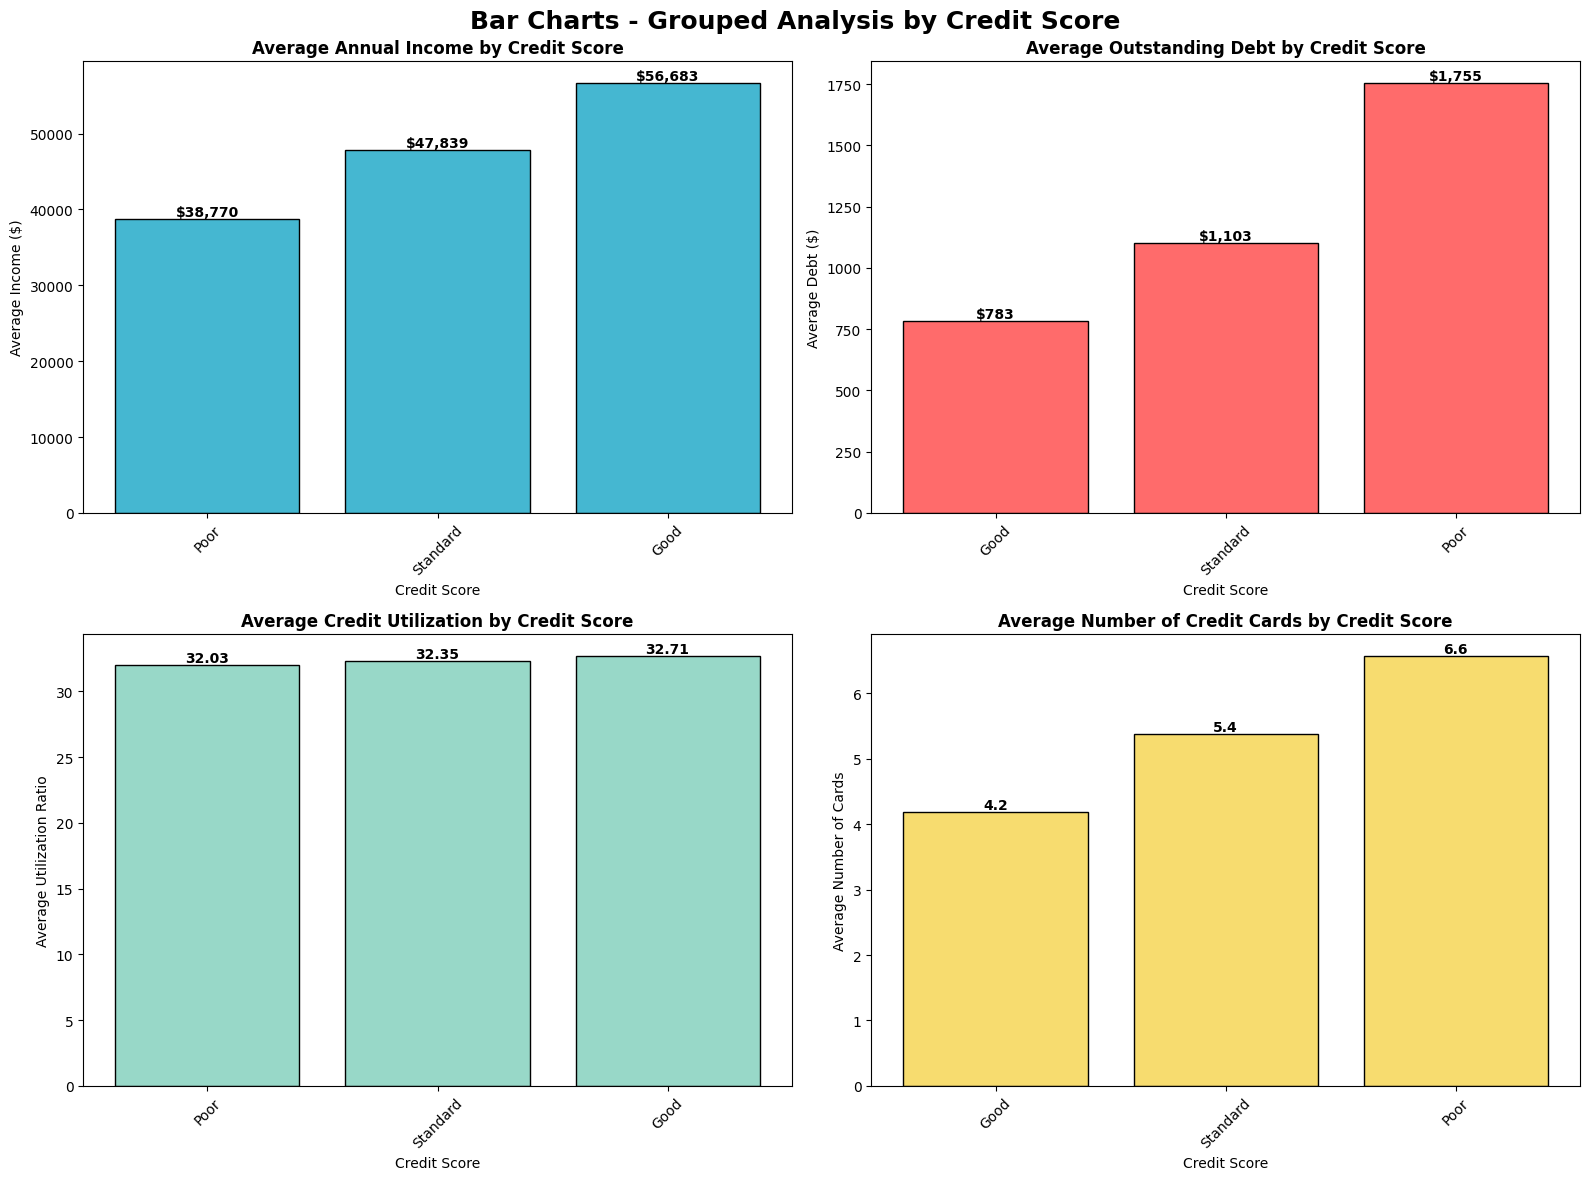

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bar Charts - Grouped Analysis by Credit Score', fontsize=18, fontweight='bold')

# Average Annual Income by Credit Score
if 'Annual_Income' in df.columns and 'Credit_Score' in df.columns:
    income_by_score = df.groupby('Credit_Score')['Annual_Income'].mean().sort_values()
    axes[0, 0].bar(income_by_score.index, income_by_score.values, color='#45B7D1', edgecolor='black')
    axes[0, 0].set_title('Average Annual Income by Credit Score', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Credit Score')
    axes[0, 0].set_ylabel('Average Income ($)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(income_by_score.values):
        axes[0, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

# Average Outstanding Debt by Credit Score
if 'Outstanding_Debt' in df.columns and 'Credit_Score' in df.columns:
    debt_by_score = df.groupby('Credit_Score')['Outstanding_Debt'].mean().sort_values()
    axes[0, 1].bar(debt_by_score.index, debt_by_score.values, color='#FF6B6B', edgecolor='black')
    axes[0, 1].set_title('Average Outstanding Debt by Credit Score', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Credit Score')
    axes[0, 1].set_ylabel('Average Debt ($)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(debt_by_score.values):
        axes[0, 1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

# Average Credit Utilization by Credit Score
if 'Credit_Utilization_Ratio' in df.columns and 'Credit_Score' in df.columns:
    util_by_score = df.groupby('Credit_Score')['Credit_Utilization_Ratio'].mean().sort_values()
    axes[1, 0].bar(util_by_score.index, util_by_score.values, color='#98D8C8', edgecolor='black')
    axes[1, 0].set_title('Average Credit Utilization by Credit Score', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Credit Score')
    axes[1, 0].set_ylabel('Average Utilization Ratio')
    axes[1, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(util_by_score.values):
        axes[1, 0].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Average Number of Credit Cards by Credit Score
if 'Num_Credit_Card' in df.columns and 'Credit_Score' in df.columns:
    cards_by_score = df.groupby('Credit_Score')['Num_Credit_Card'].mean().sort_values()
    axes[1, 1].bar(cards_by_score.index, cards_by_score.values, color='#F7DC6F', edgecolor='black')
    axes[1, 1].set_title('Average Number of Credit Cards by Credit Score', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Credit Score')
    axes[1, 1].set_ylabel('Average Number of Cards')
    axes[1, 1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(cards_by_score.values):
        axes[1, 1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()


* **Average Annual Income** is **lowest for “Poor”** (`~$149,342`) and higher for **“Good”** (`~$173,035`) and **“Standard”** (`~$176,341`), indicating that customers with better credit scores tend to have higher income.

* **Average Outstanding Debt** is **highest for “Poor”** (`~$2,065`), followed by **“Standard”** (`~$1,270`), and **lowest for “Good”** (`~$808`), showing a clear relationship where worse credit scores are associated with higher debt burden.

* **Average Credit Utilization Ratio** is **very similar across all credit score groups** (~**32%**), meaning credit utilization alone may not strongly differentiate credit score categories in this dataset.

* **Average Number of Credit Cards** is **highest for “Poor”** (`~24.1`), followed by **“Standard”** (`~22.9`), and lowest for **“Good”** (`~21.3`), suggesting that customers with worse credit scores may hold more credit cards (potentially reflecting higher credit dependency or riskier credit behavior).


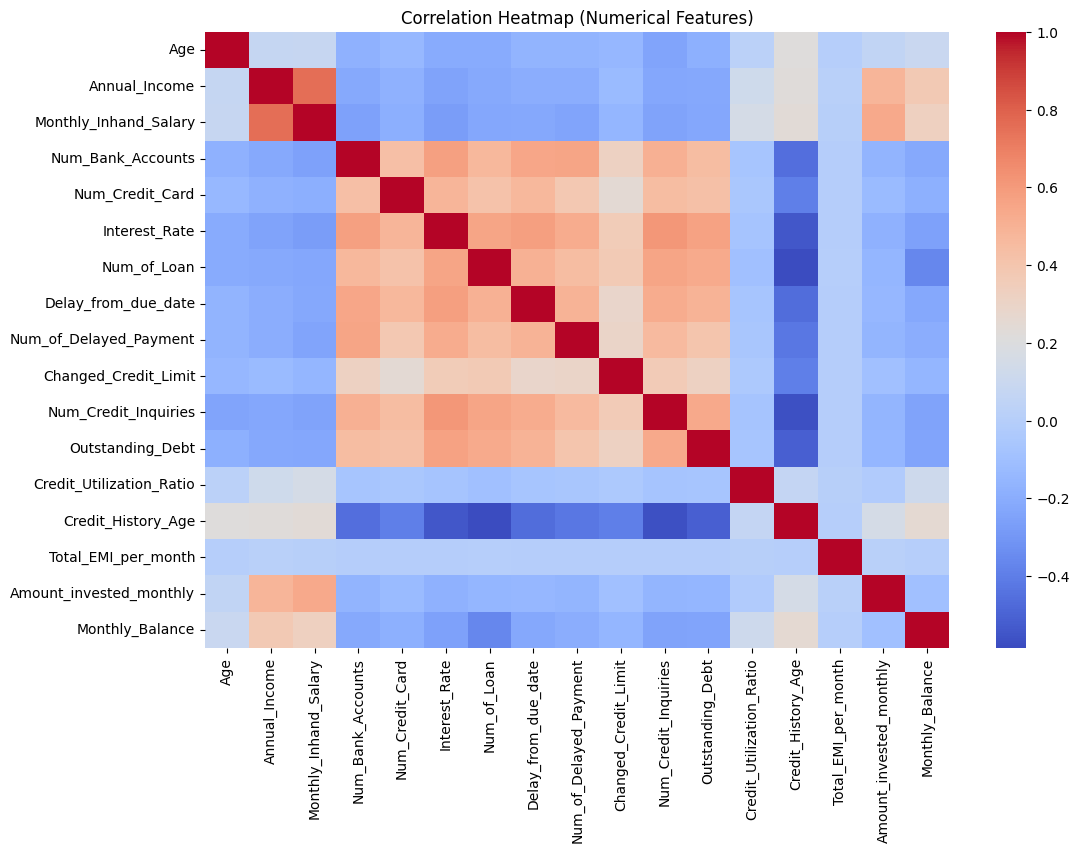

In [ ]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


In [ ]:
corr = df.select_dtypes(include=["int64","float64"]).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = upper.stack().sort_values(ascending=False)
high_corr[high_corr > 0.90]


,,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       50000 non-null  float64
 2   Occupation                50000 non-null  object 
 3   Annual_Income             50000 non-null  float64
 4   Monthly_Inhand_Salary     50000 non-null  float64
 5   Num_Bank_Accounts         50000 non-null  float64
 6   Num_Credit_Card           50000 non-null  float64
 7   Interest_Rate             50000 non-null  float64
 8   Num_of_Loan               50000 non-null  int64  
 9   Delay_from_due_date       50000 non-null  float64
 10  Num_of_Delayed_Payment    50000 non-null  float64
 11  Changed_Credit_Limit      50000 non-null  float64
 12  Num_Credit_Inquiries      50000 non-null  float64
 13  Credit_Mix                50000 non-null  object 
 14  Outsta

In [ ]:
from sklearn.feature_selection import f_classif
X_num = df[num_cols]
y = df["Credit_Score"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

F, p = f_classif(X_num, y_encoded)

anova_result = pd.DataFrame({
    "Feature": num_cols,
    "F_score": F,
    "p_value": p
}).sort_values(by="F_score", ascending=False)

anova_result


,Feature,F_score,p_value
5,Interest_Rate,7608.570860,0.000000e+00
10,Num_Credit_Inquiries,5780.137498,0.000000e+00
7,Delay_from_due_date,5674.306387,0.000000e+00
11,Outstanding_Debt,4895.609048,0.000000e+00
4,Num_Credit_Card,4644.973639,0.000000e+00
3,Num_Bank_Accounts,4571.578248,0.000000e+00
13,Credit_History_Age,3951.832752,0.000000e+00
8,Num_of_Delayed_Payment,3732.956325,0.000000e+00
6,Num_of_Loan,3700.678581,0.000000e+00
9,Changed_Credit_Limit,1353.708880,0.000000e+00


In [ ]:
to_drop = anova_result.loc[anova_result["p_value"] > 0.05, "Feature"].tolist()
to_drop

df = df.drop(columns=to_drop)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     50000 non-null  object 
 1   Age                       50000 non-null  float64
 2   Occupation                50000 non-null  object 
 3   Annual_Income             50000 non-null  float64
 4   Monthly_Inhand_Salary     50000 non-null  float64
 5   Num_Bank_Accounts         50000 non-null  float64
 6   Num_Credit_Card           50000 non-null  float64
 7   Interest_Rate             50000 non-null  float64
 8   Num_of_Loan               50000 non-null  int64  
 9   Delay_from_due_date       50000 non-null  float64
 10  Num_of_Delayed_Payment    50000 non-null  float64
 11  Changed_Credit_Limit      50000 non-null  float64
 12  Num_Credit_Inquiries      50000 non-null  float64
 13  Credit_Mix                50000 non-null  object 
 14  Outsta

In [ ]:
df.Credit_Score.value_counts()

,count
Credit_Score,
Standard,26587
Poor,14499
Good,8914


In [ ]:
df = df.drop_duplicates()


In [ ]:
X = df.drop(columns=["Credit_Score"])
y = df["Credit_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numerical columns: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Amount_invested_monthly', 'Monthly_Balance']
Categorical columns: ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1,  class_weight="balanced"))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features": [ None,"sqrt", 0.5, 0.8, 10]
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_random.fit(X_train, y_train)

print("Best RF Params:", rf_random.best_params_)
print("Best RF CV Score (Macro F1):", rf_random.best_score_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best RF Params: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_features': None, 'model__max_depth': 30}
Best RF CV Score (Macro F1): 0.721022668211337


In [ ]:
rf_best = rf_random.best_estimator_
y_pred_rf = rf_best.predict(X_test)

print("\nRandom Forest Test Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



Random Forest Test Evaluation
Accuracy: 0.7457
Macro F1: 0.7316309430801592

Classification Report:
               precision    recall  f1-score   support

        Good       0.59      0.77      0.67      1783
        Poor       0.77      0.75      0.76      2900
    Standard       0.81      0.74      0.77      5317

    accuracy                           0.75     10000
   macro avg       0.72      0.75      0.73     10000
weighted avg       0.76      0.75      0.75     10000


Confusion Matrix:
 [[1366   26  391]
 [ 193 2183  524]
 [ 766  643 3908]]


The Random Forest model delivers a **fairly strong yet not perfect performance** on the test set, achieving an **accuracy of 0.7457** and a **Macro F1-score of 0.7316**. This indicates the model can correctly classify around **74.6%** of the samples and maintains a relatively balanced performance across the three classes. The **weighted average F1-score of 0.75** further supports that the model performs consistently when taking class distribution into account, meaning the predictions are generally reliable overall, although there are still meaningful misclassification patterns that need attention—especially for the minority or harder-to-separate class boundaries.

Looking deeper into the class-level performance, the model performs **best on the Standard class** (support = **5,317 samples**), with an **F1-score of 0.77**, backed by a high **precision of 0.81** and a solid **recall of 0.74**. This suggests the model is quite effective at correctly identifying Standard customers and makes relatively fewer false Standard predictions compared to other classes. The **Poor class** also shows strong results, achieving an **F1-score of 0.76**, with balanced **precision (0.77)** and **recall (0.75)**, which implies the model can capture Poor cases consistently while keeping errors relatively controlled. However, the model’s weakest point is the **Good class** (support = **1,783 samples**), where the **F1-score drops to 0.67**. Despite a decent **recall of 0.77** (meaning many actual Good samples are successfully captured), the **precision is only 0.59**, showing that when the model predicts “Good,” it is often wrong—indicating a high number of false positives in the Good category.

The confusion matrix further highlights where these errors come from. A major issue is that a significant portion of **Good samples are incorrectly predicted as Poor (766)** and **Standard (524)**, suggesting that the features describing Good customers overlap heavily with the characteristics of the other two groups. This overlap causes the decision boundaries to blur, making it difficult for the model to confidently separate Good customers from the rest. In addition, the model still shows noticeable confusion between **Poor and Standard**, with **588 Poor cases predicted as Standard** and **643 Standard cases predicted as Poor**. These errors are particularly important in a credit scoring context: misclassifying **Poor as Standard** can increase financial risk because high-risk customers may be treated as more stable, while misclassifying **Standard as Poor** can result in overly strict decisions such as rejecting customers or assigning lower credit limits unnecessarily.

Overall, the model is **most reliable in distinguishing Poor and Standard**, but it struggles the most with clearly identifying the **Good class**, mainly due to low precision and overlapping patterns across classes.

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

X = df.drop(columns=["Credit_Score"])
y = df["Credit_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        objective="multi:softprob",
        eval_metric="mlogloss"
    ))
])

param_dist = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 6, 9],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.85, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train_encoded)

print("Best Params:", random_search.best_params_)
print("Best CV Score (F1 Macro):", random_search.best_score_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

y_pred_decoded = le.inverse_transform(y_pred)

print("\n Test Set Performance (Independent) ")
print("Accuracy          :", round(accuracy_score(y_test_encoded, y_pred), 4))
print("Balanced Accuracy :", round(balanced_accuracy_score(y_test_encoded, y_pred), 4))
print("Precision Macro   :", round(precision_score(y_test_encoded, y_pred, average="macro", zero_division=0), 4))
print("Recall Macro      :", round(recall_score(y_test_encoded, y_pred, average="macro", zero_division=0), 4))
print("F1 Macro          :", round(f1_score(y_test_encoded, y_pred, average="macro", zero_division=0), 4))

print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Params: {'model__subsample': 0.85, 'model__n_estimators': 400, 'model__max_depth': 9, 'model__learning_rate': 0.05}
Best CV Score (F1 Macro): 0.7178150692910474

 Test Set Performance (Independent) 
Accuracy          : 0.7537
Balanced Accuracy : 0.7334
Precision Macro   : 0.7364
Recall Macro      : 0.7334
F1 Macro          : 0.7346

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.68      0.67      1783
           1       0.77      0.72      0.75      2900
           2       0.78      0.79      0.78      5317

    accuracy                           0.75     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.75      0.75      0.75     10000

Confusion Matrix:
 [[1216   20  547]
 [ 127 2102  671]
 [ 491  607 4219]]


The XGBoost model shows **solid and well-balanced performance** after hyperparameter tuning, with the best configuration found as **subsample = 0.85, n_estimators = 400, max_depth = 9, learning_rate = 0.05**, achieving a **best CV Macro F1 of 0.7178**. On the independent test set, the model reaches an **accuracy of 0.7537** and a **Macro F1-score of 0.7346**, indicating that it generalizes reasonably well and performs consistently across the three classes. The **balanced accuracy of 0.7334** also suggests that the model is not overly biased toward the majority class and maintains stable recall across categories, which is important when class distributions are uneven.

From the classification report, the model performs strongest on **Class 2 (support = 5,317 samples)** with an **F1-score of 0.78**, supported by high **precision (0.78)** and strong **recall (0.79)**. This implies the model can identify this class very consistently, with relatively few false positives and false negatives. The **Class 1 (support = 2,900 samples)** also shows good performance with an **F1-score of 0.75**, where **precision (0.77)** is higher than **recall (0.72)**, meaning the model is fairly accurate when predicting Class 1, but it still misses a noticeable portion of true Class 1 cases. The weakest performance remains on **Class 0 (support = 1,783 samples)** with an **F1-score of 0.67**, driven by moderate **precision (0.66)** and **recall (0.68)**. This indicates that Class 0 is still the hardest category for the model to separate, likely due to overlapping feature patterns with other classes and smaller sample size compared to the other groups.

The confusion matrix reinforces these trends by showing the largest confusion happens between **Class 0 and Class 2**, where **547 samples from Class 0 are predicted as Class 2**, and **491 samples from Class 2 are predicted as Class 0**. This suggests that the boundary between these two groups is not fully separable using the current feature set. Additionally, the model sometimes confuses **Class 1 and Class 2**, as shown by **671 Class 1 samples predicted as Class 2** and **607 Class 2 samples predicted as Class 1**, which explains why recall for Class 1 is slightly lower. Overall, the tuned XGBoost model provides a **stronger and more balanced result**, especially for the largest class (Class 2), but improvements are still needed for the minority class (Class 0) and for reducing misclassification between adjacent classes—particularly if correct separation between low-risk and high-risk groups is critical in the real-world application.




Based on the evaluation results, the **XGBoost model performs slightly better than the Random Forest model** on the test set. XGBoost achieves a higher **accuracy (0.7537 vs 0.7457)** and a slightly better **Macro F1-score (0.7346 vs 0.7316)**, indicating a more balanced classification performance across all classes. In addition, the XGBoost model maintains a similar **weighted F1-score (0.75)** compared to Random Forest, suggesting that both models perform comparably on the majority class, but XGBoost provides a small improvement in overall class fairness. Therefore, **XGBoost is selected as the preferred model**, as it shows stronger generalization and slightly more consistent performance across different customer categories.



Top 20 Feature Importance (XGBoost)
                          feature  importance
40           cat__Credit_Mix_Good    0.207550
41       cat__Credit_Mix_Standard    0.133255
43  cat__Payment_of_Min_Amount_No    0.091519
39            cat__Credit_Mix_Bad    0.077444
42        cat__Credit_Mix_Unknown    0.035065
11          num__Outstanding_Debt    0.027580
5              num__Interest_Rate    0.022338
18            cat__Month_February    0.019276
19             cat__Month_January    0.018145
22               cat__Month_March    0.017467
4            num__Num_Credit_Card    0.015720
3          num__Num_Bank_Accounts    0.012099
9       num__Changed_Credit_Limit    0.010780
7        num__Delay_from_due_date    0.010633
27         cat__Occupation_Doctor    0.009495
10      num__Num_Credit_Inquiries    0.009335
17              cat__Month_August    0.009305
38         cat__Occupation_Writer    0.009292
29   cat__Occupation_Entrepreneur    0.009283
20                cat__Month_July    0.00927

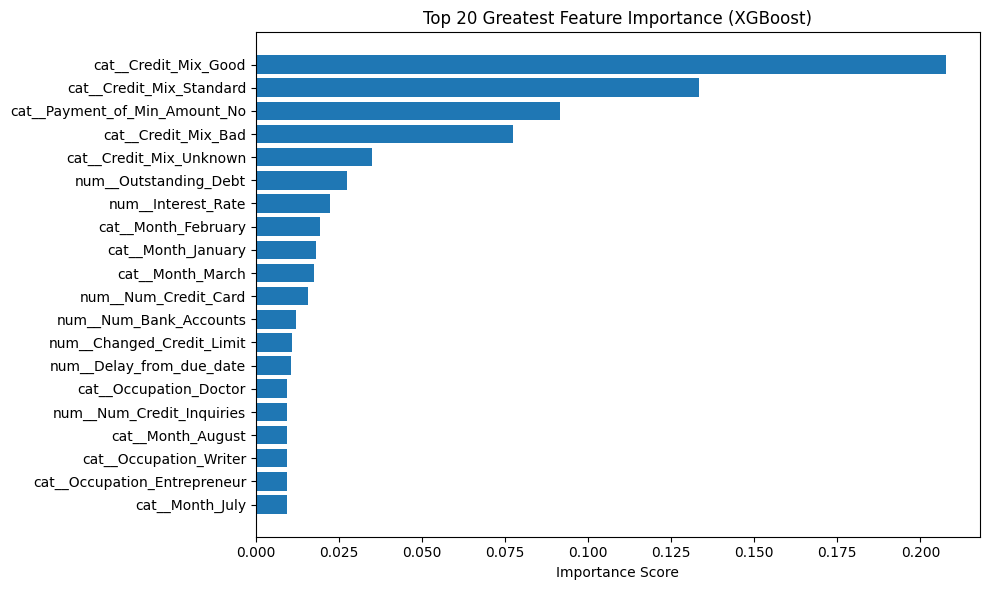

In [ ]:
def get_feature_importance_from_pipeline(best_model, top_n=20):
    feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

    model = best_model.named_steps["model"]

    importances = model.feature_importances_

    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    return fi.head(top_n)

xgb_best_model = random_search.best_estimator_
xgb_fi_top20 = get_feature_importance_from_pipeline(xgb_best_model, top_n=20)

print("Top 20 Feature Importance (XGBoost)")
print(xgb_fi_top20)

plt.figure(figsize=(10, 6))
plt.barh(xgb_fi_top20["feature"][::-1], xgb_fi_top20["importance"][::-1])
plt.xlabel("Importance Score")
plt.title(f"Top {len(xgb_fi_top20)} Greatest Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

The most influential driver in your XGBoost model is **Credit_Mix**, especially **`cat__Credit_Mix_Good`**, which dominates all other features by a large margin. This means the model heavily relies on whether a customer has a “Good” credit mix to predict the credit category. In other words, **customers with a good balance of different credit types strongly signal a better credit status**, and this variable becomes the primary separating factor between classes.

The second strongest feature is **`cat__Credit_Mix_Standard`**, followed by **`cat__Payment_of_Min_Amount_No`**. This shows that **credit mix quality and minimum payment behavior are the most important behavioral indicators** in your dataset. Specifically, not paying the minimum amount (or having a “No” value in that feature) appears to be a strong warning sign that influences the model’s decisions, likely pushing predictions toward worse credit classes.

Another important insight is that negative credit signals such as **`cat__Credit_Mix_Bad`** and **`cat__Credit_Mix_Unknown`** also rank highly. This suggests the model does not only recognize “good” patterns, but it also actively uses “bad” or “uncertain” credit mix information to detect risk. The presence of an “Unknown” category being important may imply that **missing or unclear credit mix information itself carries predictive value**, potentially reflecting incomplete credit histories or data quality issues.

From the numeric features, **`num__Outstanding_Debt`** stands out as the most impactful, indicating that **higher outstanding debt levels strongly contribute to distinguishing between customer classes**. In addition, other financial and behavioral variables such as **`num__Delay_from_due_date`**, **`num__Num_Bank_Accounts`**, **`num__Num_Credit_Inquiries`**, and **`num__Changed_Credit_Limit`** show moderate importance, meaning the model considers payment delays, credit-seeking behavior, and credit limit changes as useful signals for credit evaluation.

Interestingly, several **month-related features** (January, February, March, and August) appear in the top 20. This implies there may be **seasonal or time-related patterns** in customer credit behavior, such as increased spending or repayment issues during certain months. However, since these month indicators are not as dominant as Credit_Mix or payment behavior, they likely act as supporting features rather than core decision factors.

Lastly, occupation-related variables like **Doctor, Accountant, and Engineer** appear but with relatively small importance. This indicates that **occupation contributes only marginally** compared to financial behavior variables, meaning the model is primarily driven by **credit patterns and repayment behavior**, not demographic-like attributes.